In [7]:
import pandas as pd

# If your file has data on the first sheet
df = pd.read_excel('E Commerce Dataset.xlsx')

# If your data is on a specific sheet, add sheet_name:
df = pd.read_excel('E Commerce Dataset.xlsx', sheet_name='E Comm')  # change 'Sheet1' to your actual sheet name

print(df.shape)
df.head()

(5630, 20)


,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


# Data Cleaning

In [8]:
# 1. Check missing values
df.isnull().sum()

# 2. Fill or drop nulls (common for this dataset)
df.fillna(df.median(numeric_only=True), inplace=True)  # for numeric columns
df.fillna(df.mode().iloc[0], inplace=True)             # for categorical columns

# 3. Check for duplicates
df.duplicated().sum()
df.drop_duplicates(inplace=True)

# 4. Fix data types if needed
df.dtypes

# 5. Check for outliers in key columns
df[['Tenure', 'CashbackAmount', 'OrderCount']].describe()

,Tenure,CashbackAmount,OrderCount
count,5630.000000,5630.000000,5630.000000
mean,10.134103,177.223030,2.961812
std,8.357951,49.207036,2.879248
min,0.000000,0.000000,1.000000
25%,3.000000,145.770000,1.000000
50%,9.000000,163.280000,2.000000
75%,15.000000,196.392500,3.000000
max,61.000000,324.990000,16.000000


In [9]:
import pandas as pd
import numpy as np

# cleaning step 1: load the data
df = pd.read_excel('E Commerce Dataset.xlsx', sheet_name='E Comm')  # change 'Sheet1' to your actual sheet name
print("original shape:", df.shape)


# cleaning step 2: check missing values
print("\nMissing values:")
print(df.isnull().sum())

original shape: (5630, 20)

Missing values:
CustomerID                       0
Churn                            0
Tenure                         264
PreferredLoginDevice             0
CityTier                         0
WarehouseToHome                251
PreferredPaymentMode             0
Gender                           0
HourSpendOnApp                 255
NumberOfDeviceRegistered         0
PreferedOrderCat                 0
SatisfactionScore                0
MaritalStatus                    0
NumberOfAddress                  0
Complain                         0
OrderAmountHikeFromlastYear    265
CouponUsed                     256
OrderCount                     258
DaySinceLastOrder              307
CashbackAmount                   0
dtype: int64


In [10]:
# cleaning step 3: Fix CustomerID — treat as string
df['CustomerID'] = df['CustomerID'].astype(str)

# cleaning step 4: Fill missing NUMERIC columns with median
numeric_cols = [
    'Tenure', 'WarehouseToHome', 'HourSpendOnApp',
    'OrderAmountHikeFromlastYear', 'CouponUsed',
    'OrderCount', 'DaySinceLastOrder', 'CashbackAmount'
]
for col in numeric_cols:
    median_val = df[col].median()
    df[col].fillna(median_val, inplace=True)
    print(f" Filled {col} with median: {median_val}")

 Filled Tenure with median: 9.0
 Filled WarehouseToHome with median: 14.0
 Filled HourSpendOnApp with median: 3.0
 Filled OrderAmountHikeFromlastYear with median: 15.0
 Filled CouponUsed with median: 1.0
 Filled OrderCount with median: 2.0
 Filled DaySinceLastOrder with median: 3.0
 Filled CashbackAmount with median: 163.28


C:\Users\Admin\AppData\Local\Temp\ipykernel_7560\4210682798.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(median_val, inplace=True)


In [11]:
# Step 5: Fill missing CATEGORICAL columns with mode
categorical_cols = [
    'PreferredLoginDevice', 'PreferredPaymentMode',
    'Gender', 'PreferedOrderCat', 'MaritalStatus'
]
for col in categorical_cols:
    mode_val = df[col].mode()[0]
    df[col].fillna(mode_val, inplace=True)
    print(f" Filled {col} with mode: {mode_val}")

 Filled PreferredLoginDevice with mode: Mobile Phone
 Filled PreferredPaymentMode with mode: Debit Card
 Filled Gender with mode: Male
 Filled PreferedOrderCat with mode: Laptop & Accessory
 Filled MaritalStatus with mode: Married


C:\Users\Admin\AppData\Local\Temp\ipykernel_7560\1144600474.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(mode_val, inplace=True)


In [12]:
# Step 6: Drop duplicates
before = df.shape[0]
df.drop_duplicates(inplace=True)
print(f"\n Removed {before - df.shape[0]} duplicate rows")

# Step 7: Fix data types
df['Churn'] = df['Churn'].astype(int)
df['CityTier'] = df['CityTier'].astype(int)
df['SatisfactionScore'] = df['SatisfactionScore'].astype(int)
df['Complain'] = df['Complain'].astype(int)
df['NumberOfDeviceRegistered'] = df['NumberOfDeviceRegistered'].astype(int)
df['NumberOfAddress'] = df['NumberOfAddress'].astype(int)

# Step 8: Verify — no missing values remaining
print("\nMissing values after cleaning:")
print(df.isnull().sum())
print("\nFinal shape:", df.shape)


 Removed 0 duplicate rows

Missing values after cleaning:
CustomerID                     0
Churn                          0
Tenure                         0
PreferredLoginDevice           0
CityTier                       0
WarehouseToHome                0
PreferredPaymentMode           0
Gender                         0
HourSpendOnApp                 0
NumberOfDeviceRegistered       0
PreferedOrderCat               0
SatisfactionScore              0
MaritalStatus                  0
NumberOfAddress                0
Complain                       0
OrderAmountHikeFromlastYear    0
CouponUsed                     0
OrderCount                     0
DaySinceLastOrder              0
CashbackAmount                 0
dtype: int64

Final shape: (5630, 20)


In [13]:
# splitting the file into 3 files
customers = df[['CustomerID', 'Gender', 'MaritalStatus', 'CityTier', 
                'Tenure', 'NumberOfAddress', 'NumberOfDeviceRegistered']].copy()

behavior = df[['CustomerID', 'PreferredLoginDevice', 'PreferredPaymentMode',
               'PreferedOrderCat', 'HourSpendOnApp', 
               'SatisfactionScore', 'Complain']].copy()

orders = df[['CustomerID', 'OrderCount', 'OrderAmountHikeFromlastYear',
             'CouponUsed', 'CashbackAmount', 
             'DaySinceLastOrder', 'WarehouseToHome', 'Churn']].copy()

customers.to_csv('customers.csv', index=False)
behavior.to_csv('behavior.csv', index=False)
orders.to_csv('orders.csv', index=False)

In [21]:
# Merge all 3 tables back together using CustomerID as the key
df = customers.merge(behavior, on='CustomerID').merge(orders, on='CustomerID')
df.to_csv('Ecommerce.csv', index=False)
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())





Shape: (5630, 20)
Columns: ['CustomerID', 'Gender', 'MaritalStatus', 'CityTier', 'Tenure', 'NumberOfAddress', 'NumberOfDeviceRegistered', 'PreferredLoginDevice', 'PreferredPaymentMode', 'PreferedOrderCat', 'HourSpendOnApp', 'SatisfactionScore', 'Complain', 'OrderCount', 'OrderAmountHikeFromlastYear', 'CouponUsed', 'CashbackAmount', 'DaySinceLastOrder', 'WarehouseToHome', 'Churn']


In [16]:
df.head()

,CustomerID,Gender,MaritalStatus,CityTier,Tenure,NumberOfAddress,NumberOfDeviceRegistered,PreferredLoginDevice,PreferredPaymentMode,PreferedOrderCat,HourSpendOnApp,SatisfactionScore,Complain,OrderCount,OrderAmountHikeFromlastYear,CouponUsed,CashbackAmount,DaySinceLastOrder,WarehouseToHome,Churn
0,50001,Female,Single,3,4.0,9,3,Mobile Phone,Debit Card,Laptop & Accessory,3.0,2,1,1.0,11.0,1.0,159.93,5.0,6.0,1
1,50002,Male,Single,1,9.0,7,4,Phone,UPI,Mobile,3.0,3,1,1.0,15.0,0.0,120.90,0.0,8.0,1
2,50003,Male,Single,1,9.0,6,4,Phone,Debit Card,Mobile,2.0,3,1,1.0,14.0,0.0,120.28,3.0,30.0,1
3,50004,Male,Single,3,0.0,8,4,Phone,Debit Card,Laptop & Accessory,2.0,5,0,1.0,23.0,0.0,134.07,3.0,15.0,1
4,50005,Male,Single,1,0.0,3,3,Phone,CC,Mobile,3.0,5,0,1.0,11.0,1.0,129.60,3.0,12.0,1


# EDA 

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
## importing and loading data
# Settings
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
pd.set_option('display.max_columns', None)

# Load cleaned merged dataframe (after cleaning + splitting + merging back)
df = pd.read_csv('Ecommerce.csv')
df['CustomerID'] = df['CustomerID'].astype(str)
print("Shape:", df.shape)
df.head()

Shape: (5630, 20)


,CustomerID,Gender,MaritalStatus,CityTier,Tenure,NumberOfAddress,NumberOfDeviceRegistered,PreferredLoginDevice,PreferredPaymentMode,PreferedOrderCat,HourSpendOnApp,SatisfactionScore,Complain,OrderCount,OrderAmountHikeFromlastYear,CouponUsed,CashbackAmount,DaySinceLastOrder,WarehouseToHome,Churn
0,50001,Female,Single,3,4.0,9,3,Mobile Phone,Debit Card,Laptop & Accessory,3.0,2,1,1.0,11.0,1.0,159.93,5.0,6.0,1
1,50002,Male,Single,1,9.0,7,4,Phone,UPI,Mobile,3.0,3,1,1.0,15.0,0.0,120.90,0.0,8.0,1
2,50003,Male,Single,1,9.0,6,4,Phone,Debit Card,Mobile,2.0,3,1,1.0,14.0,0.0,120.28,3.0,30.0,1
3,50004,Male,Single,3,0.0,8,4,Phone,Debit Card,Laptop & Accessory,2.0,5,0,1.0,23.0,0.0,134.07,3.0,15.0,1
4,50005,Male,Single,1,0.0,3,3,Phone,CC,Mobile,3.0,5,0,1.0,11.0,1.0,129.60,3.0,12.0,1


In [23]:
## statical summary
print("    NUMERIC SUMMARY ")
display(df.describe().round(2))

print("\n  CATEGORICAL SUMMARY ")
cat_cols = ['PreferredLoginDevice', 'PreferredPaymentMode', 
            'Gender', 'PreferedOrderCat', 'MaritalStatus']
for col in cat_cols:
    print(f"\n{col}:\n{df[col].value_counts()}")

    NUMERIC SUMMARY 


,CityTier,Tenure,NumberOfAddress,NumberOfDeviceRegistered,HourSpendOnApp,SatisfactionScore,Complain,OrderCount,OrderAmountHikeFromlastYear,CouponUsed,CashbackAmount,DaySinceLastOrder,WarehouseToHome,Churn
count,5630.00,5630.00,5630.00,5630.00,5630.00,5630.00,5630.00,5630.00,5630.00,5630.00,5630.00,5630.00,5630.00,5630.00
mean,1.65,10.13,4.21,3.69,2.93,3.07,0.28,2.96,15.67,1.72,177.22,4.46,15.57,0.17
std,0.92,8.36,2.58,1.02,0.71,1.38,0.45,2.88,3.59,1.86,49.21,3.57,8.35,0.37
min,1.00,0.00,1.00,1.00,0.00,1.00,0.00,1.00,11.00,0.00,0.00,0.00,5.00,0.00
25%,1.00,3.00,2.00,3.00,2.00,2.00,0.00,1.00,13.00,1.00,145.77,2.00,9.00,0.00
50%,1.00,9.00,3.00,4.00,3.00,3.00,0.00,2.00,15.00,1.00,163.28,3.00,14.00,0.00
75%,3.00,15.00,6.00,4.00,3.00,4.00,1.00,3.00,18.00,2.00,196.39,7.00,20.00,0.00
max,3.00,61.00,22.00,6.00,5.00,5.00,1.00,16.00,26.00,16.00,324.99,46.00,127.00,1.00



  CATEGORICAL SUMMARY 

PreferredLoginDevice:
PreferredLoginDevice
Mobile Phone    2765
Computer        1634
Phone           1231
Name: count, dtype: int64

PreferredPaymentMode:
PreferredPaymentMode
Debit Card          2314
Credit Card         1501
E wallet             614
UPI                  414
COD                  365
CC                   273
Cash on Delivery     149
Name: count, dtype: int64

Gender:
Gender
Male      3384
Female    2246
Name: count, dtype: int64

PreferedOrderCat:
PreferedOrderCat
Laptop & Accessory    2050
Mobile Phone          1271
Fashion                826
Mobile                 809
Grocery                410
Others                 264
Name: count, dtype: int64

MaritalStatus:
MaritalStatus
Married     2986
Single      1796
Divorced     848
Name: count, dtype: int64


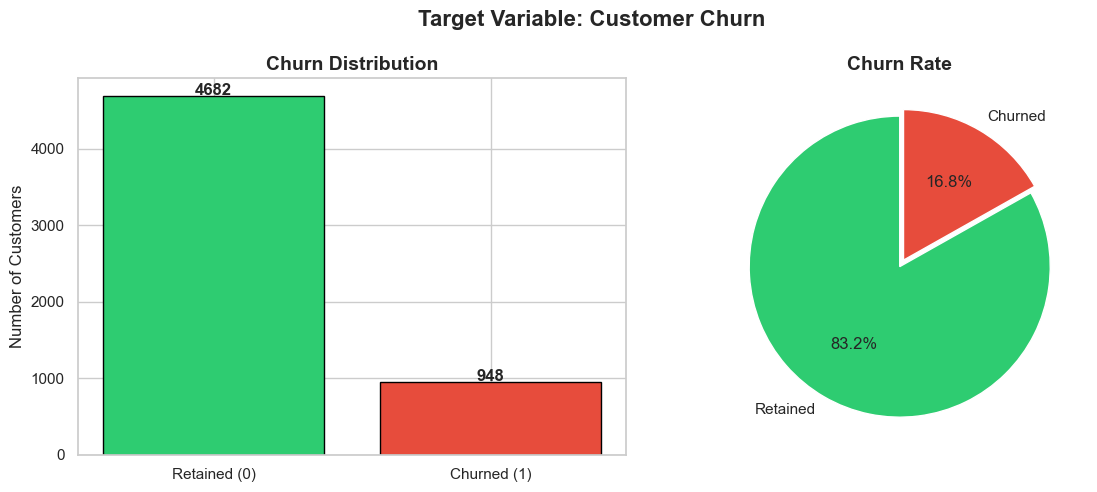

Churn Rate: 16.8%


In [24]:
## churn distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count plot
churn_counts = df['Churn'].value_counts()
axes[0].bar(['Retained (0)', 'Churned (1)'], churn_counts.values, 
            color=['#2ecc71', '#e74c3c'], edgecolor='black')
axes[0].set_title('Churn Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Customers')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 20, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(churn_counts.values, labels=['Retained', 'Churned'],
            autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'],
            startangle=90, explode=(0, 0.05))
axes[1].set_title('Churn Rate', fontsize=14, fontweight='bold')

plt.suptitle('Target Variable: Customer Churn', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Churn Rate: {df['Churn'].mean()*100:.1f}%")

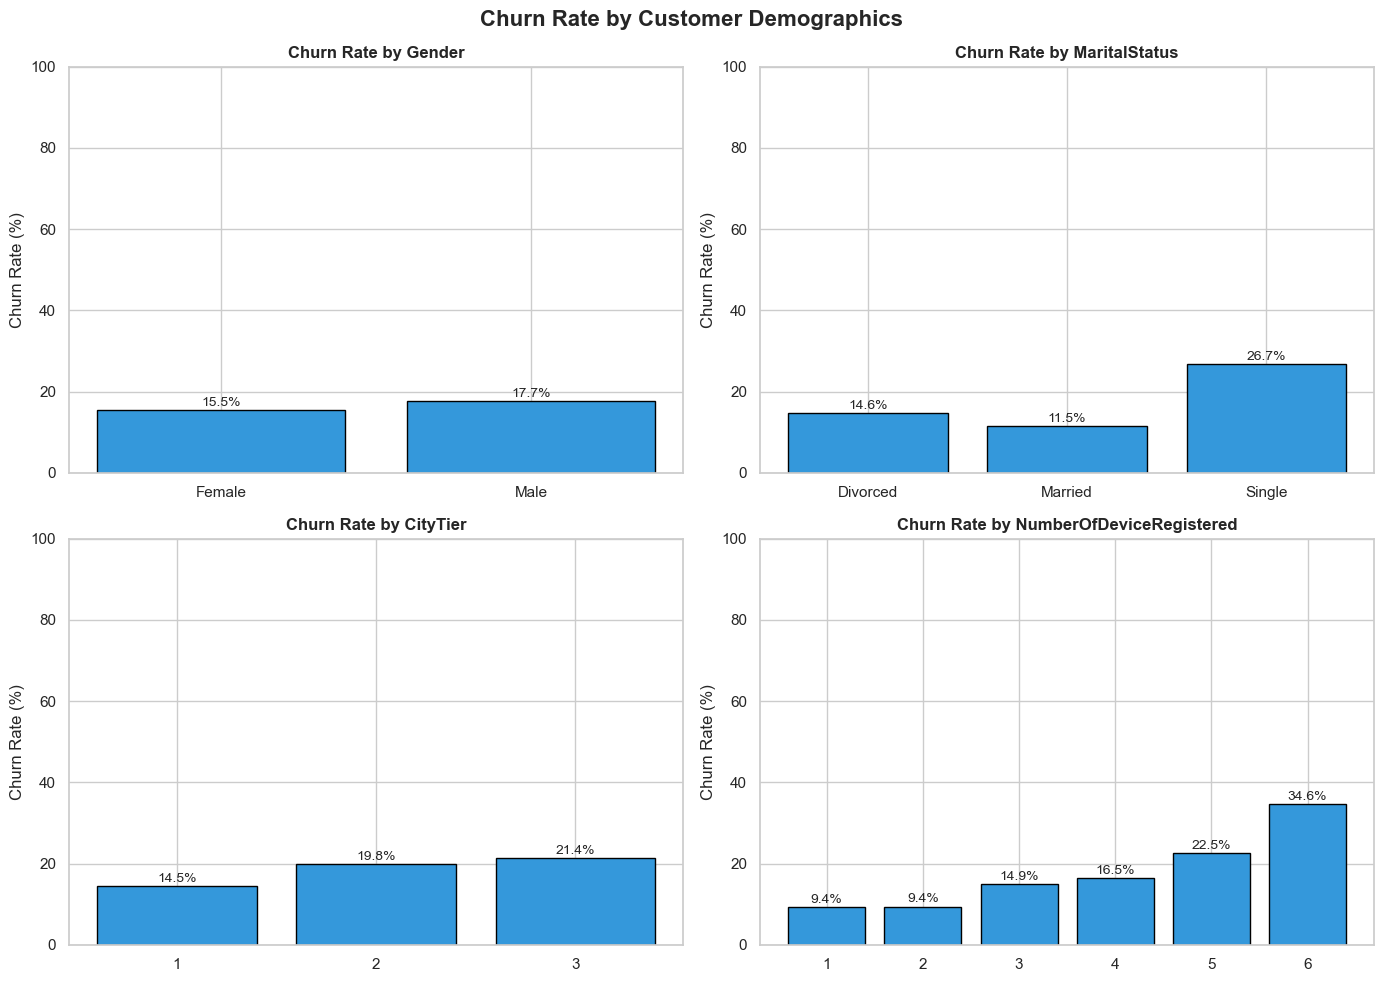

In [25]:
## chrun distribution by deographics
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

demo_cols = ['Gender', 'MaritalStatus', 'CityTier', 'NumberOfDeviceRegistered']

for ax, col in zip(axes.flatten(), demo_cols):
    churn_rate = df.groupby(col)['Churn'].mean().reset_index()
    churn_rate['Churn'] = churn_rate['Churn'] * 100
    bars = ax.bar(churn_rate[col].astype(str), churn_rate['Churn'],
                  color='#3498db', edgecolor='black')
    ax.set_title(f'Churn Rate by {col}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Churn Rate (%)')
    ax.set_ylim(0, 100)
    for bar, val in zip(bars, churn_rate['Churn']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{val:.1f}%', ha='center', fontsize=10)

plt.suptitle('Churn Rate by Customer Demographics', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('churn_by_demographics.png', dpi=150, bbox_inches='tight')
plt.show()

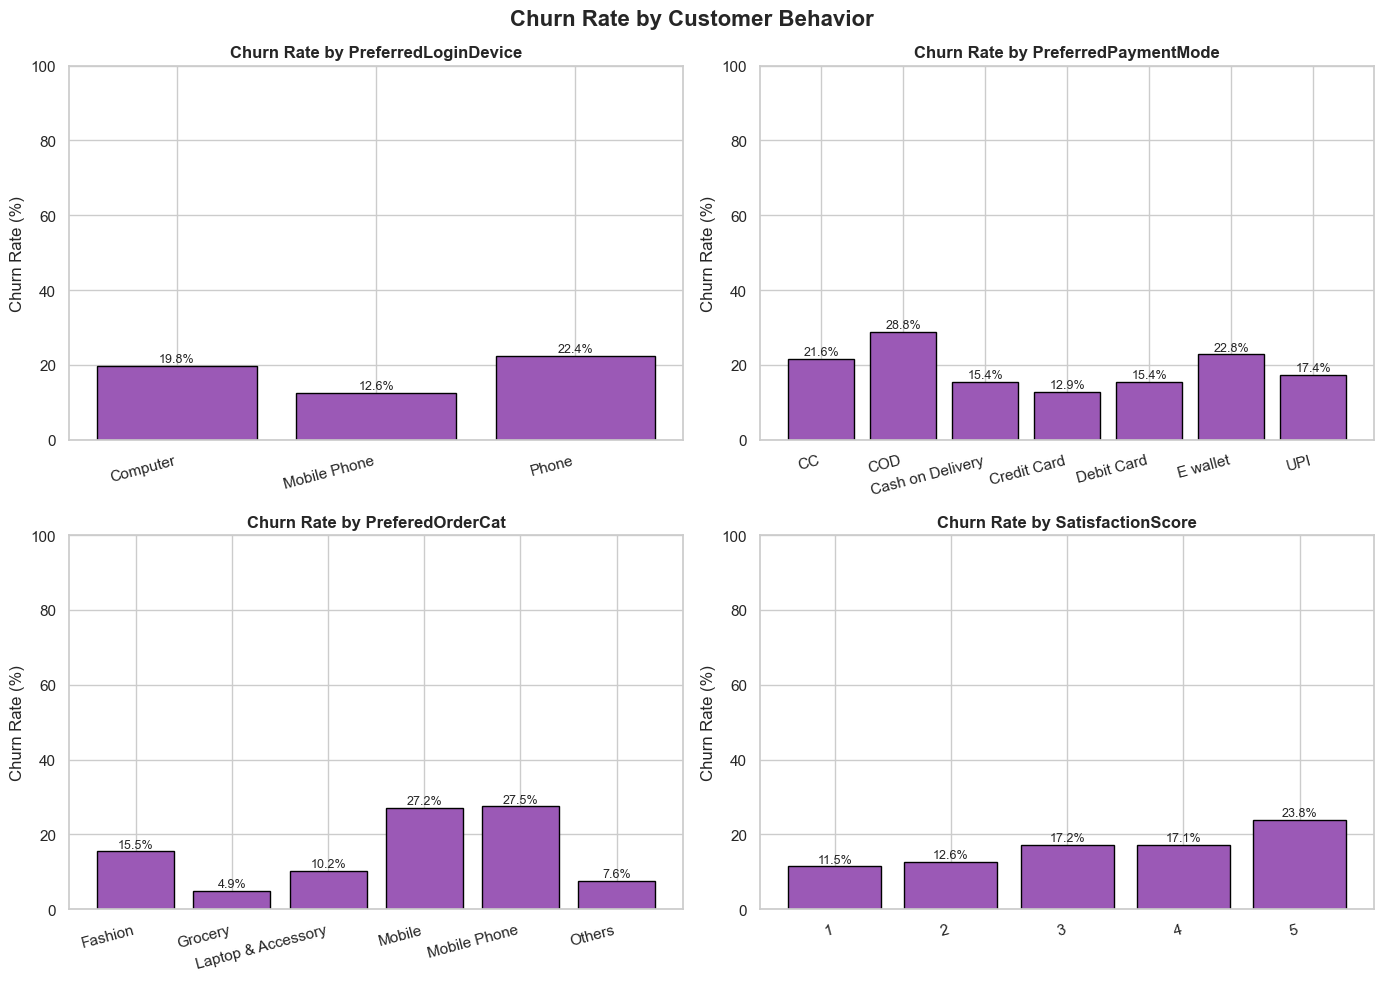

In [26]:
## churn by behavior
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

behavior_cols = ['PreferredLoginDevice', 'PreferredPaymentMode', 
                 'PreferedOrderCat', 'SatisfactionScore']

for ax, col in zip(axes.flatten(), behavior_cols):
    churn_rate = df.groupby(col)['Churn'].mean().reset_index()
    churn_rate['Churn'] = churn_rate['Churn'] * 100
    bars = ax.bar(churn_rate[col].astype(str), churn_rate['Churn'],
                  color='#9b59b6', edgecolor='black')
    ax.set_title(f'Churn Rate by {col}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Churn Rate (%)')
    ax.set_ylim(0, 100)
    plt.setp(ax.get_xticklabels(), rotation=15, ha='right')
    for bar, val in zip(bars, churn_rate['Churn']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{val:.1f}%', ha='center', fontsize=9)

plt.suptitle('Churn Rate by Customer Behavior', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('churn_by_behavior.png', dpi=150, bbox_inches='tight')
plt.show()

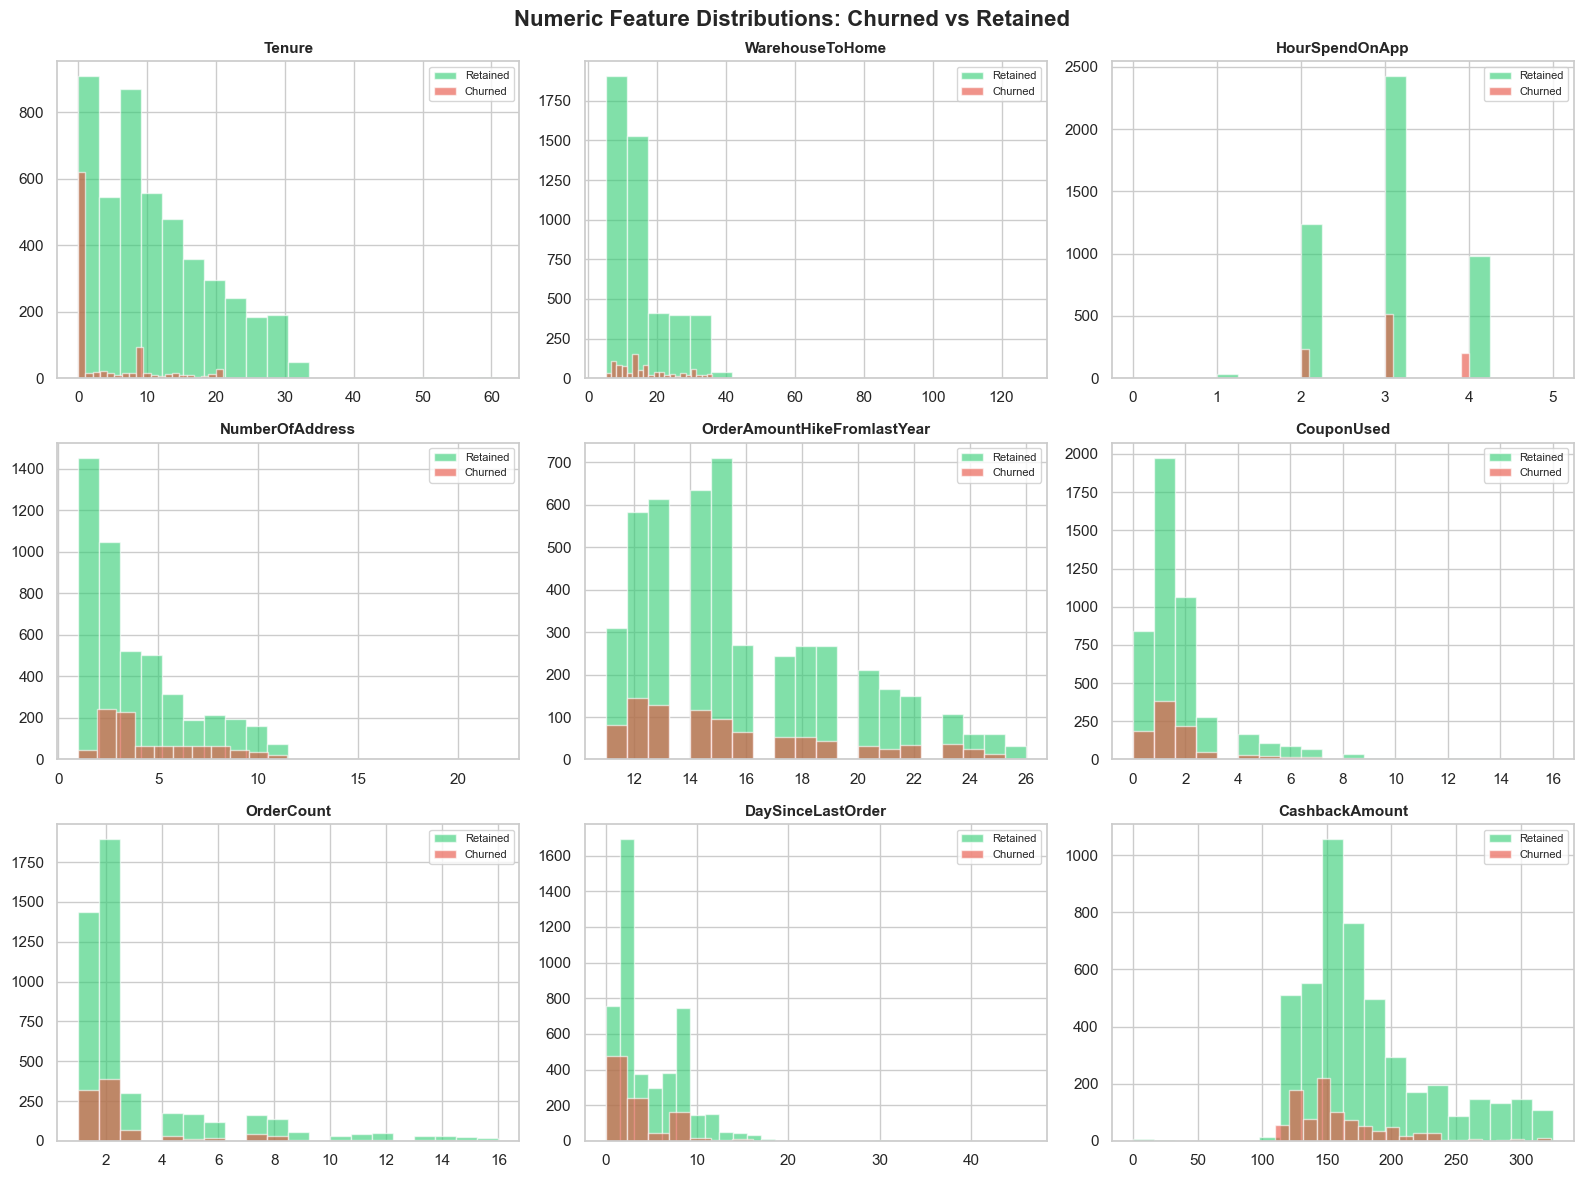

In [27]:
numeric_cols = ['Tenure', 'WarehouseToHome', 'HourSpendOnApp',
                'NumberOfAddress', 'OrderAmountHikeFromlastYear',
                'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount']

fig, axes = plt.subplots(3, 3, figsize=(16, 12))

for ax, col in zip(axes.flatten(), numeric_cols):
    # Overlay churned vs retained
    df[df['Churn']==0][col].hist(ax=ax, alpha=0.6, color='#2ecc71', 
                                  label='Retained', bins=20)
    df[df['Churn']==1][col].hist(ax=ax, alpha=0.6, color='#e74c3c', 
                                  label='Churned', bins=20)
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.legend(fontsize=8)

plt.suptitle('Numeric Feature Distributions: Churned vs Retained', 
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('numeric_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

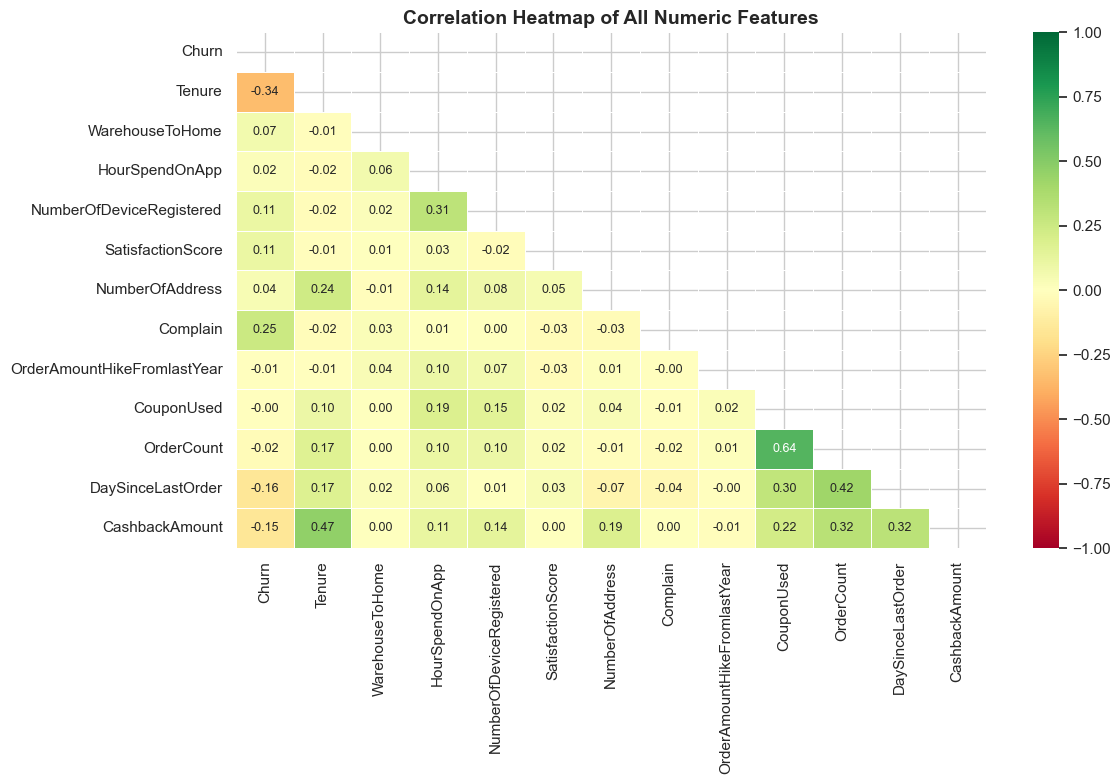

=== Top Correlations with Churn ===
Churn                          1.000
Complain                       0.250
NumberOfDeviceRegistered       0.108
SatisfactionScore              0.105
WarehouseToHome                0.070
NumberOfAddress                0.044
HourSpendOnApp                 0.019
CouponUsed                    -0.001
OrderAmountHikeFromlastYear   -0.007
OrderCount                    -0.024
CashbackAmount                -0.154
DaySinceLastOrder             -0.156
Tenure                        -0.338
Name: Churn, dtype: float64


In [28]:
## correlation heatmap
plt.figure(figsize=(12, 8))

corr_cols = ['Churn', 'Tenure', 'WarehouseToHome', 'HourSpendOnApp',
             'NumberOfDeviceRegistered', 'SatisfactionScore', 'NumberOfAddress',
             'Complain', 'OrderAmountHikeFromlastYear', 'CouponUsed',
             'OrderCount', 'DaySinceLastOrder', 'CashbackAmount']

corr_matrix = df[corr_cols].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, vmin=-1, vmax=1,
            linewidths=0.5, annot_kws={'size': 9})

plt.title('Correlation Heatmap of All Numeric Features', 
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Print top correlations with Churn
print("=== Top Correlations with Churn ===")
print(corr_matrix['Churn'].sort_values(ascending=False).round(3))

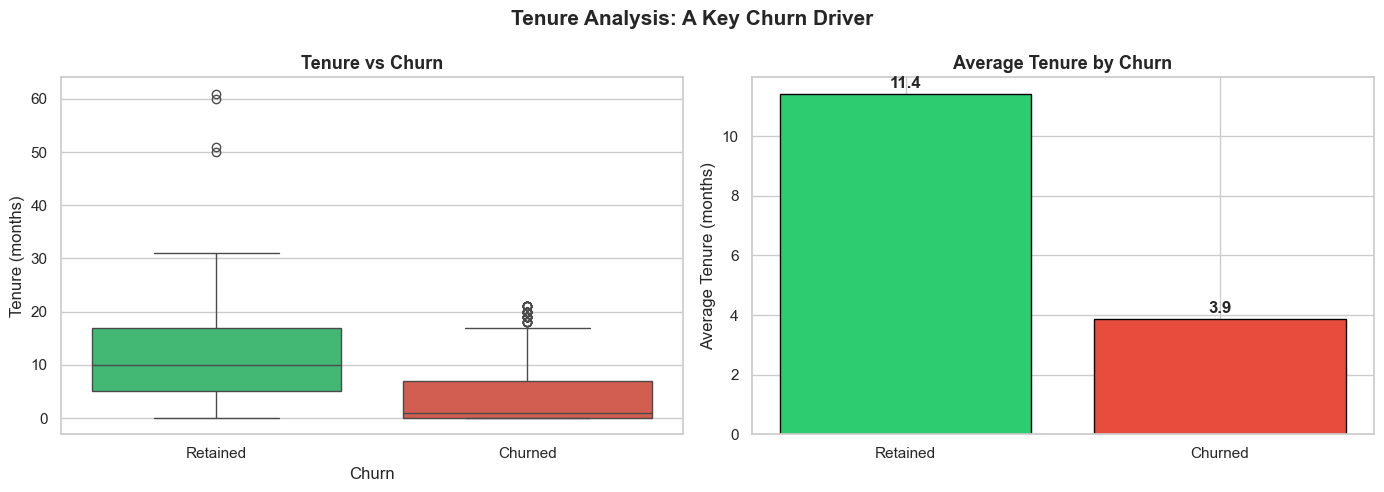

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='Churn', y='Tenure',
            hue='Churn', palette=['#2ecc71', '#e74c3c'],
            legend=False, ax=axes[0])
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Retained', 'Churned'])
axes[0].set_title('Tenure vs Churn', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Tenure (months)')

avg_tenure = df.groupby('Churn')['Tenure'].mean()
axes[1].bar(['Retained', 'Churned'], avg_tenure.values,
            color=['#2ecc71', '#e74c3c'], edgecolor='black')
axes[1].set_title('Average Tenure by Churn', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Average Tenure (months)')
for i, v in enumerate(avg_tenure.values):
    axes[1].text(i, v + 0.2, f'{v:.1f}', ha='center', fontweight='bold')

plt.suptitle('Tenure Analysis: A Key Churn Driver', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('tenure_vs_churn.png', dpi=150, bbox_inches='tight')
plt.show()

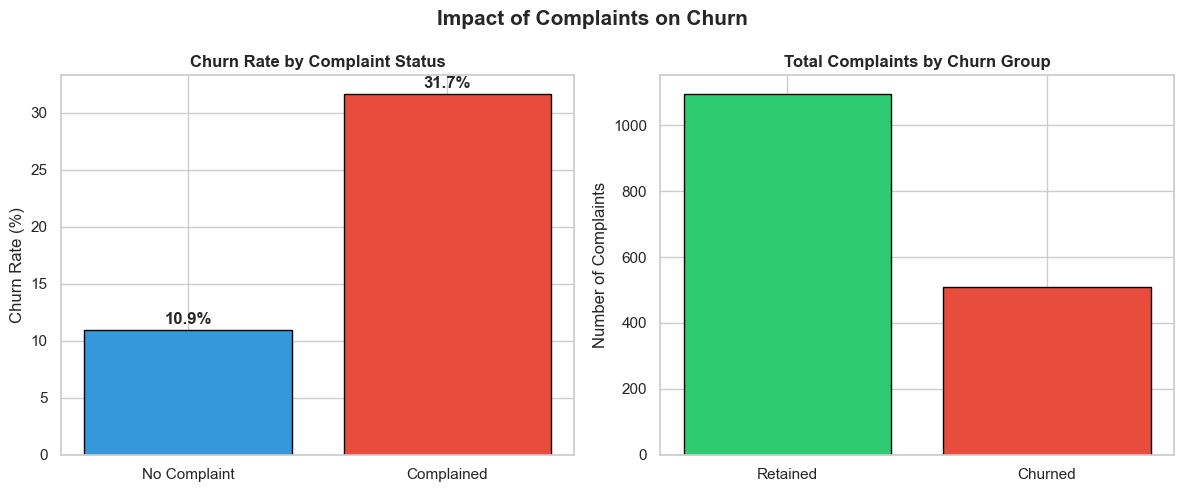

In [30]:
## complaints impact on chrun
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Churn rate by complaint
complain_churn = df.groupby('Complain')['Churn'].mean() * 100
axes[0].bar(['No Complaint', 'Complained'], complain_churn.values,
            color=['#3498db', '#e74c3c'], edgecolor='black')
axes[0].set_title('Churn Rate by Complaint Status', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Churn Rate (%)')
for i, v in enumerate(complain_churn.values):
    axes[0].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

# Complaint count by churn
complain_count = df.groupby('Churn')['Complain'].sum()
axes[1].bar(['Retained', 'Churned'], complain_count.values,
            color=['#2ecc71', '#e74c3c'], edgecolor='black')
axes[1].set_title('Total Complaints by Churn Group', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Number of Complaints')

plt.suptitle('Impact of Complaints on Churn', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('complaints_vs_churn.png', dpi=150, bbox_inches='tight')
plt.show()

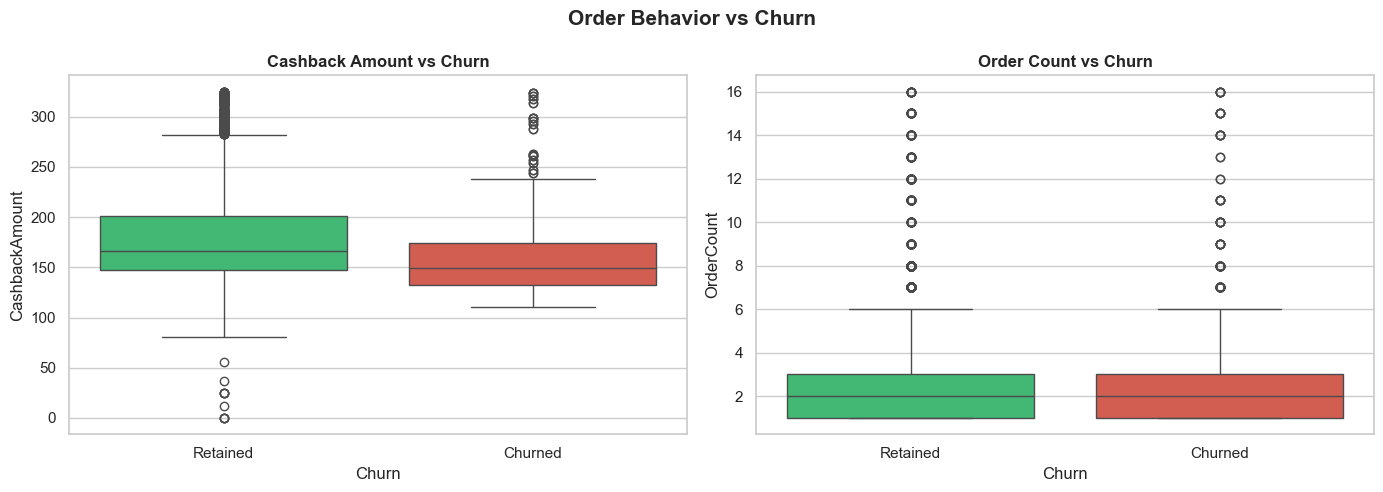

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='Churn', y='CashbackAmount',
            hue='Churn', palette=['#2ecc71', '#e74c3c'],
            legend=False, ax=axes[0])
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Retained', 'Churned'])
axes[0].set_title('Cashback Amount vs Churn', fontsize=12, fontweight='bold')

sns.boxplot(data=df, x='Churn', y='OrderCount',
            hue='Churn', palette=['#2ecc71', '#e74c3c'],
            legend=False, ax=axes[1])
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Retained', 'Churned'])
axes[1].set_title('Order Count vs Churn', fontsize=12, fontweight='bold')

plt.suptitle('Order Behavior vs Churn', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('orders_cashback_vs_churn.png', dpi=150, bbox_inches='tight')
plt.show()

In [32]:
print("=" * 55)
print("         EDA KEY INSIGHTS SUMMARY")
print("=" * 55)

print(f"\n📌 Total Customers: {len(df):,}")
print(f"📌 Churn Rate: {df['Churn'].mean()*100:.1f}%")
print(f"📌 Retained Customers: {(df['Churn']==0).sum():,}")
print(f"📌 Churned Customers: {(df['Churn']==1).sum():,}")

print(f"\n📌 Avg Tenure (Retained): {df[df['Churn']==0]['Tenure'].mean():.1f} months")
print(f"📌 Avg Tenure (Churned): {df[df['Churn']==1]['Tenure'].mean():.1f} months")

print(f"\n📌 Complaint-Churn Rate: {df[df['Complain']==1]['Churn'].mean()*100:.1f}%")
print(f"📌 No Complaint-Churn Rate: {df[df['Complain']==0]['Churn'].mean()*100:.1f}%")

print(f"\n📌 Avg Cashback (Retained): ${df[df['Churn']==0]['CashbackAmount'].mean():.2f}")
print(f"📌 Avg Cashback (Churned): ${df[df['Churn']==1]['CashbackAmount'].mean():.2f}")

print(f"\n📌 Top Churn Category: {df[df['Churn']==1]['PreferedOrderCat'].mode()[0]}")
print(f"📌 Top Payment Mode (Churned): {df[df['Churn']==1]['PreferredPaymentMode'].mode()[0]}")
print("=" * 55)

         EDA KEY INSIGHTS SUMMARY

📌 Total Customers: 5,630
📌 Churn Rate: 16.8%
📌 Retained Customers: 4,682
📌 Churned Customers: 948

📌 Avg Tenure (Retained): 11.4 months
📌 Avg Tenure (Churned): 3.9 months

📌 Complaint-Churn Rate: 31.7%
📌 No Complaint-Churn Rate: 10.9%

📌 Avg Cashback (Retained): $180.64
📌 Avg Cashback (Churned): $160.37

📌 Top Churn Category: Mobile Phone
📌 Top Payment Mode (Churned): Debit Card


## checking for outliers

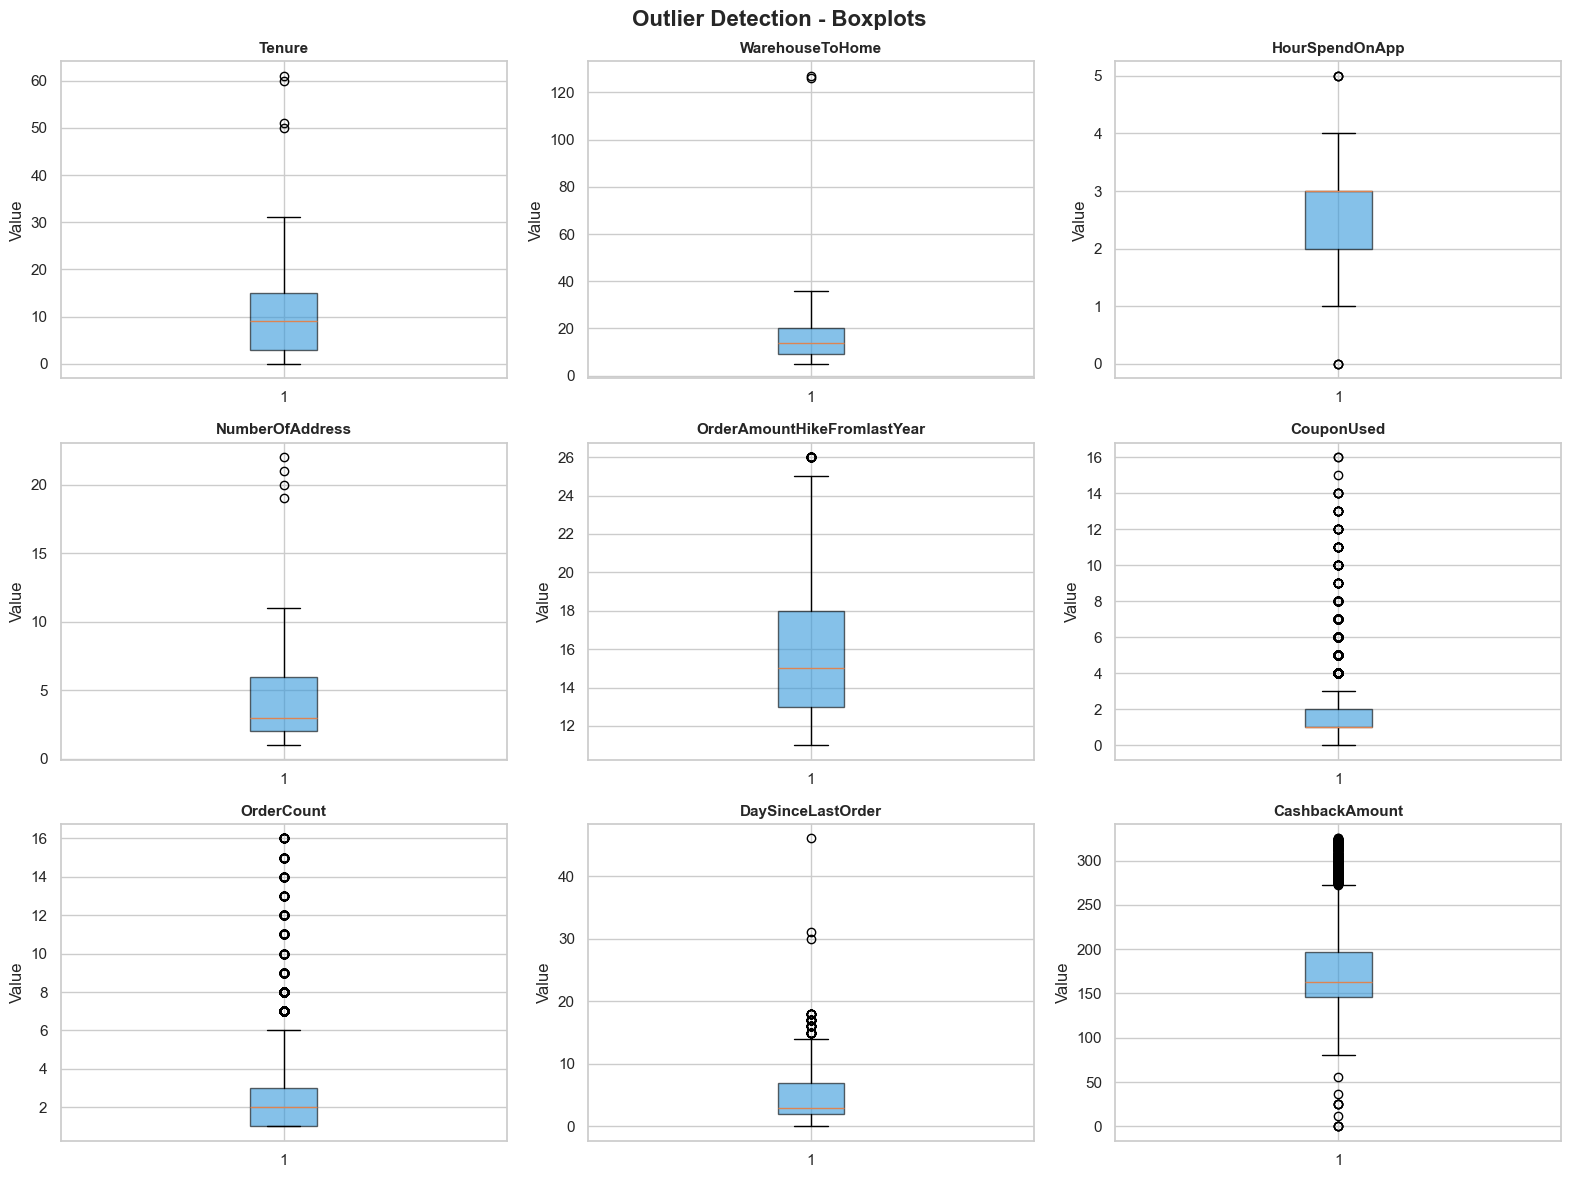

=== Outlier Counts (IQR Method) ===
Tenure: 4 outliers (0.1%)
WarehouseToHome: 2 outliers (0.0%)
HourSpendOnApp: 6 outliers (0.1%)
NumberOfAddress: 4 outliers (0.1%)
OrderAmountHikeFromlastYear: 33 outliers (0.6%)
CouponUsed: 629 outliers (11.2%)
OrderCount: 703 outliers (12.5%)
DaySinceLastOrder: 62 outliers (1.1%)
CashbackAmount: 438 outliers (7.8%)


In [39]:
# Outlier Detection using IQR
numeric_cols = ['Tenure', 'WarehouseToHome', 'HourSpendOnApp',
                'NumberOfAddress', 'OrderAmountHikeFromlastYear',
                'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount']

fig, axes = plt.subplots(3, 3, figsize=(16, 12))

for ax, col in zip(axes.flatten(), numeric_cols):
    ax.boxplot(df[col].dropna(), vert=True, patch_artist=True,
               boxprops=dict(facecolor='#3498db', alpha=0.6))
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.set_ylabel('Value')

plt.suptitle('Outlier Detection - Boxplots', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('outliers_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

# Print outlier counts per column
print("=== Outlier Counts (IQR Method) ===")
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)]
    print(f"{col}: {len(outliers)} outliers ({len(outliers)/len(df)*100:.1f}%)")

In [44]:
# Cap outliers instead of removing them using IQR (Winsorization)
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[col] = df[col].clip(lower, upper)

df.to_csv('Ecommerce.csv', index=False)
print("Shape after capping:", df.shape)


Shape after capping: (5630, 20)


## Feature Engineering

In [45]:
# Create new meaningful features from existing ones

# 1. Engagement Score — how active is the customer
df['EngagementScore'] = (df['HourSpendOnApp'] * df['OrderCount']) / (df['DaySinceLastOrder'] + 1)

# 2. Coupon Dependency — how much they rely on coupons
df['CouponDependency'] = df['CouponUsed'] / (df['OrderCount'] + 1)

# 3. Address Mobility — changing addresses often = less loyal
df['AddressMobility'] = df['NumberOfAddress'] / (df['Tenure'] + 1)

# 4. Cashback Per Order
df['CashbackPerOrder'] = df['CashbackAmount'] / (df['OrderCount'] + 1)

# 5. Is New Customer (Tenure less than 3 months)
df['IsNewCustomer'] = (df['Tenure'] <= 3).astype(int)

print("✅ New features created!")
print("New shape:", df.shape)
print("\nNew columns added:")
new_cols = ['EngagementScore', 'CouponDependency', 
            'AddressMobility', 'CashbackPerOrder', 'IsNewCustomer']
print(df[new_cols].describe().round(3))

✅ New features created!
New shape: (5630, 25)

New columns added:
       EngagementScore  CouponDependency  AddressMobility  CashbackPerOrder  \
count         5630.000          5630.000         5630.000          5630.000   
mean             1.766             0.398            0.854            57.916   
std              1.353             0.247            1.249            22.295   
min              0.100             0.000            0.029             9.977   
25%              0.750             0.250            0.214            41.500   
50%              1.500             0.500            0.400            57.628   
75%              2.250             0.500            1.000            71.430   
max             18.000             1.167           10.000           136.163   

       IsNewCustomer  
count       5630.000  
mean           0.277  
std            0.448  
min            0.000  
25%            0.000  
50%            0.000  
75%            1.000  
max            1.000  


In [46]:
# One-hot encode categorical columns
cat_cols = ['PreferredLoginDevice', 'PreferredPaymentMode',
            'PreferedOrderCat', 'Gender', 'MaritalStatus']

df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=False)

# Drop CustomerID (not needed for modeling)
df_encoded = df_encoded.drop(columns=['CustomerID'])

print("✅ Encoding done!")
print("Shape after encoding:", df_encoded.shape)
print("\nAll columns:")
print(df_encoded.columns.tolist())

✅ Encoding done!
Shape after encoding: (5630, 40)

All columns:
['CityTier', 'Tenure', 'NumberOfAddress', 'NumberOfDeviceRegistered', 'HourSpendOnApp', 'SatisfactionScore', 'Complain', 'OrderCount', 'OrderAmountHikeFromlastYear', 'CouponUsed', 'CashbackAmount', 'DaySinceLastOrder', 'WarehouseToHome', 'Churn', 'EngagementScore', 'CouponDependency', 'AddressMobility', 'CashbackPerOrder', 'IsNewCustomer', 'PreferredLoginDevice_Computer', 'PreferredLoginDevice_Mobile Phone', 'PreferredLoginDevice_Phone', 'PreferredPaymentMode_CC', 'PreferredPaymentMode_COD', 'PreferredPaymentMode_Cash on Delivery', 'PreferredPaymentMode_Credit Card', 'PreferredPaymentMode_Debit Card', 'PreferredPaymentMode_E wallet', 'PreferredPaymentMode_UPI', 'PreferedOrderCat_Fashion', 'PreferedOrderCat_Grocery', 'PreferedOrderCat_Laptop & Accessory', 'PreferedOrderCat_Mobile', 'PreferedOrderCat_Mobile Phone', 'PreferedOrderCat_Others', 'Gender_Female', 'Gender_Male', 'MaritalStatus_Divorced', 'MaritalStatus_Married', '

In [47]:
from sklearn.model_selection import train_test_split

# Target and features
X = df_encoded.drop(columns=['Churn'])
y = df_encoded['Churn']

print("Class distribution:")
print(y.value_counts())
print(f"\nChurn Rate: {y.mean()*100:.1f}%")

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\n✅ Train size: {X_train.shape}")
print(f"✅ Test size: {X_test.shape}")

Class distribution:
Churn
0    4682
1     948
Name: count, dtype: int64

Churn Rate: 16.8%

✅ Train size: (4504, 39)
✅ Test size: (1126, 39)


In [49]:
## handeling class imbalance with SMOTE
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE:", pd.Series(y_train_bal).value_counts().to_dict())
print(f"\n Balanced training set: {X_train_bal.shape}")

Before SMOTE: {0: 3746, 1: 758}
After SMOTE: {0: 3746, 1: 3746}

 Balanced training set: (7492, 39)


# Building the Model

## NOTE: 
I WILL BE USING PyCaret which is an AutoML Library that automatically trains 18+ models at once 
compares them all in one table and picks the best one for the dataset
it also handels preprocessing automatically as well.


In [54]:
!pip install "pycaret==3.3.2"

  Using cached numpy-1.26.4.tar.gz (15.8 MB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Installing backend dependencies: started
  Installing backend dependencies: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'error'


  error: subprocess-exited-with-error
  
  Preparing metadata (pyproject.toml) did not run successfully.
  exit code: 1
  
  [21 lines of output]
  + C:\Users\Admin\anaconda3\python.exe C:\Users\Admin\AppData\Local\Temp\pip-install-yzeyd0p5\numpy_dbbbe0c08d754a51b75f8c3475aa69f1\vendored-meson\meson\meson.py setup C:\Users\Admin\AppData\Local\Temp\pip-install-yzeyd0p5\numpy_dbbbe0c08d754a51b75f8c3475aa69f1 C:\Users\Admin\AppData\Local\Temp\pip-install-yzeyd0p5\numpy_dbbbe0c08d754a51b75f8c3475aa69f1\.mesonpy-jv3nxgll -Dbuildtype=release -Db_ndebug=if-release -Db_vscrt=md --native-file=C:\Users\Admin\AppData\Local\Temp\pip-install-yzeyd0p5\numpy_dbbbe0c08d754a51b75f8c3475aa69f1\.mesonpy-jv3nxgll\meson-python-native-file.ini
  The Meson build system
  Version: 1.2.99
  Source dir: C:\Users\Admin\AppData\Local\Temp\pip-install-yzeyd0p5\numpy_dbbbe0c08d754a51b75f8c3475aa69f1
  Build dir: C:\Users\Admin\AppData\Local\Temp\pip-install-yzeyd0p5\numpy_dbbbe0c08d754a51b75f8c3475aa69f1\.mesonpy-j

In [53]:
from pycaret.classification import *

# Initialize PyCaret setup
clf = setup(
    data=df_encoded,
    target='Churn',
    session_id=42,
    fix_imbalance=True,        # handles class imbalance automatically
    normalize=True,             # normalizes numeric features
    transformation=True,        # applies power transformation
    remove_multicollinearity=True,  # removes highly correlated features
    multicollinearity_threshold=0.95,
    verbose=True
)

RuntimeError: ('Pycaret only supports python 3.9, 3.10, 3.11. Your actual Python version: ', sys.version_info(major=3, minor=13, micro=9, releaselevel='final', serial=0), 'Please DOWNGRADE your Python version.')